In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, SimpleRNN, LSTM, GRU,
    Bidirectional, Dropout, Input
)
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv("../data/apple.csv")

In [3]:
df = df.sort_values("Date").reset_index(drop=True)

In [4]:
df.head()

,Date,Open,High,Low,Close
0,1980-12-12 00:00:00-05:00,0.098834,0.099264,0.098834,0.098834
1,1980-12-15 00:00:00-05:00,0.094108,0.094108,0.093678,0.093678
2,1980-12-16 00:00:00-05:00,0.087232,0.087232,0.086802,0.086802
3,1980-12-17 00:00:00-05:00,0.088951,0.089381,0.088951,0.088951
4,1980-12-18 00:00:00-05:00,0.091530,0.091959,0.091530,0.091530


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11094 entries, 0 to 11093
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11094 non-null  object 
 1   Open    11094 non-null  float64
 2   High    11094 non-null  float64
 3   Low     11094 non-null  float64
 4   Close   11094 non-null  float64
dtypes: float64(4), object(1)
memory usage: 433.5+ KB


In [6]:
df.describe()

,Open,High,Low,Close
count,11094.000000,11094.000000,11094.000000,11094.000000
mean,23.236654,23.484468,23.001626,23.254564
std,49.129620,49.645173,48.654514,49.178271
min,0.038245,0.038245,0.037815,0.037815
25%,0.242896,0.248067,0.237920,0.242953
50%,0.442782,0.451501,0.435876,0.444634
75%,18.083088,18.278464,17.904287,18.107803
max,247.960007,250.800003,246.259995,248.130005


In [7]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [8]:
df.dtypes

Date      object
Open     float64
High     float64
Low      float64
Close    float64
dtype: object

In [9]:
df.isnull().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.nunique()

Date     11094
Open     10472
High     10304
Low      10117
Close     8084
dtype: int64

In [12]:
df.shape

(11094, 5)

In [13]:
data = df[["Close"]].values

In [14]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

In [15]:
SEQ_LEN = 10

def create_sequences(data, seq_len):
    x, y = [], []
    for i in range(seq_len, len(data)):
        x.append(data[i - seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

x, y = create_sequences(data_scaled, SEQ_LEN)

In [16]:
split = int(len(x) * 0.8)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

In [17]:
x = x.reshape((x.shape[0], x.shape[1], 1))
x = x.reshape((x.shape[0],  x.shape[1],  1))

In [18]:
print(f"\nTraining data: {x_train.shape}")
print(f"Testing data: {x_test.shape}")


Training data: (8867, 10)
Testing data: (2217, 10)


In [19]:
def build_and_evaluate(model, model_name, x_train, y_train, x_test, y_test, scaler, epochs=50):
    print(f"  Model: {model_name}")

    early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    print(f"Trained for {len(history.history['loss'])} epochs (early stopping)")

    y_pred_scaled = model.predict(x_test, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_real = scaler.inverse_transform(y_test.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    print(f"  RMSE: {rmse:.4f} USD")
    print(f"  MAE:  {mae:.4f} USD")

    return history, y_pred, y_real, rmse, mae

In [20]:
model_rnn = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(1)
])
model_rnn.compile(optimizer="adam", loss="mse")

history_rnn, pred_rnn, y_real, rmse_rnn, mae_rnn = build_and_evaluate(
    model_rnn, "SimpleRNN", x_train, y_train, x_test, y_test, scaler
)

  Model: SimpleRNN
Trained for 21 epochs (early stopping)
  RMSE: 15.7455 USD
  MAE:  10.8929 USD


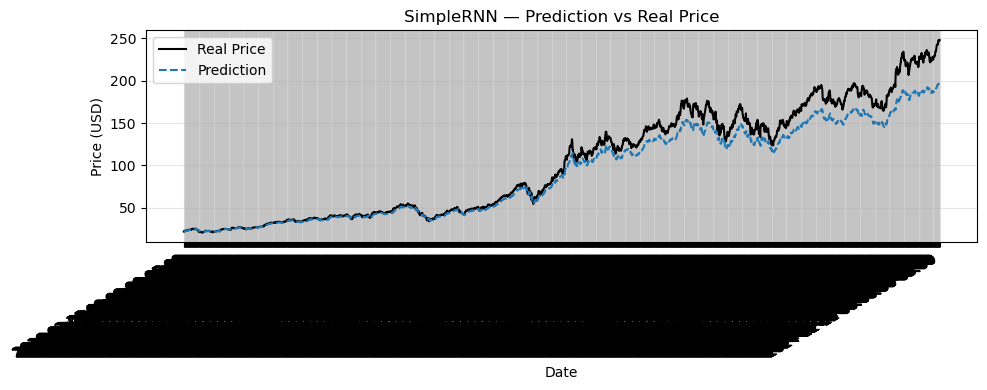

In [21]:
dates_test = df["Date"].values[SEQ_LEN + split:]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates_test, y_real, label="Real Price", color="black", linewidth=1.5)
ax.plot(dates_test, pred_rnn, label="Prediction", color="tab:blue", linewidth=1.5, linestyle="--")
ax.set_title("SimpleRNN — Prediction vs Real Price", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

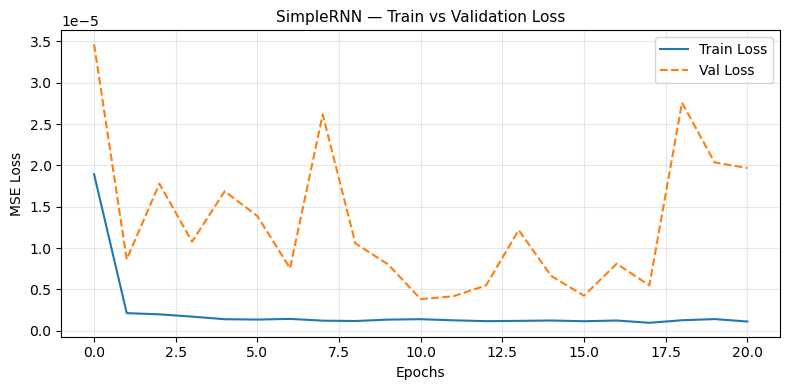

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_rnn.history["loss"], label="Train Loss", linewidth=1.5)
ax.plot(history_rnn.history["val_loss"], label="Val Loss", linewidth=1.5, linestyle="--")
ax.set_title("SimpleRNN — Train vs Validation Loss", fontsize=11)
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
model_lstm = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(1)
])
model_lstm.compile(optimizer="adam", loss="mse")

history_lstm, pred_lstm, _, rmse_lstm, mae_lstm = build_and_evaluate(
    model_lstm, "LSTM", x_train, y_train, x_test, y_test, scaler
)

  Model: LSTM
Trained for 50 epochs (early stopping)
  RMSE: 3.8739 USD
  MAE:  2.5355 USD


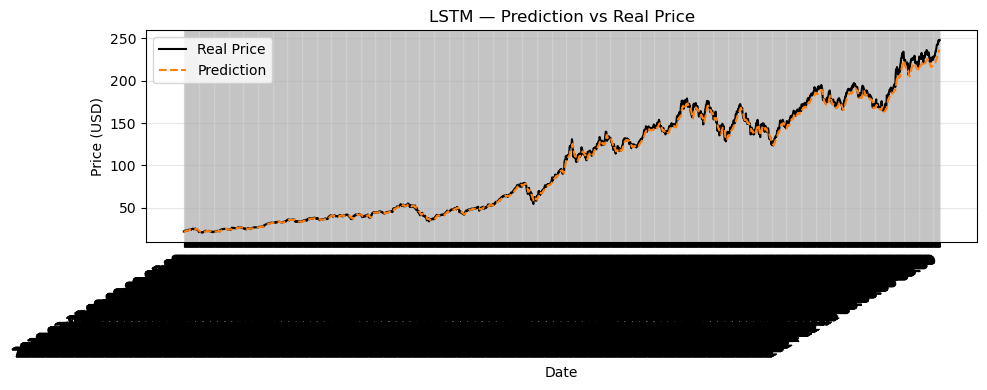

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates_test, y_real, label="Real Price", color="black", linewidth=1.5)
ax.plot(dates_test, pred_lstm, label="Prediction", color="tab:orange", linewidth=1.5, linestyle="--")
ax.set_title("LSTM — Prediction vs Real Price", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

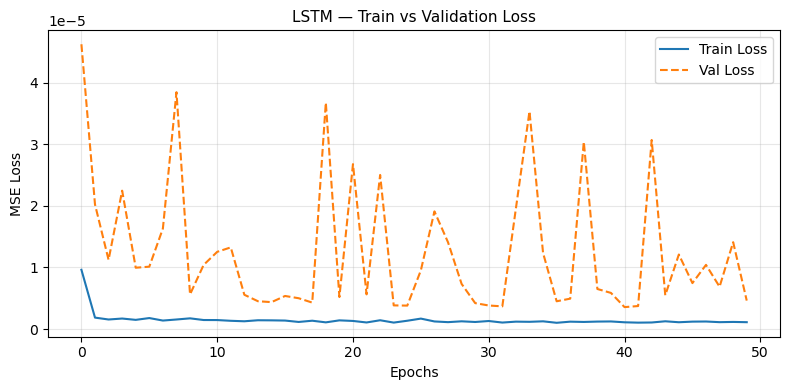

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_lstm.history["loss"], label="Train Loss", linewidth=1.5)
ax.plot(history_lstm.history["val_loss"], label="Val Loss", linewidth=1.5, linestyle="--")
ax.set_title("LSTM — Train vs Validation Loss", fontsize=11)
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
model_gru = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(1)
])
model_gru.compile(optimizer="adam", loss="mse")

history_gru, pred_gru, _, rmse_gru, mae_gru = build_and_evaluate(
    model_gru, "GRU", x_train, y_train, x_test, y_test, scaler
)

  Model: GRU
Trained for 28 epochs (early stopping)
  RMSE: 7.7305 USD
  MAE:  5.5201 USD


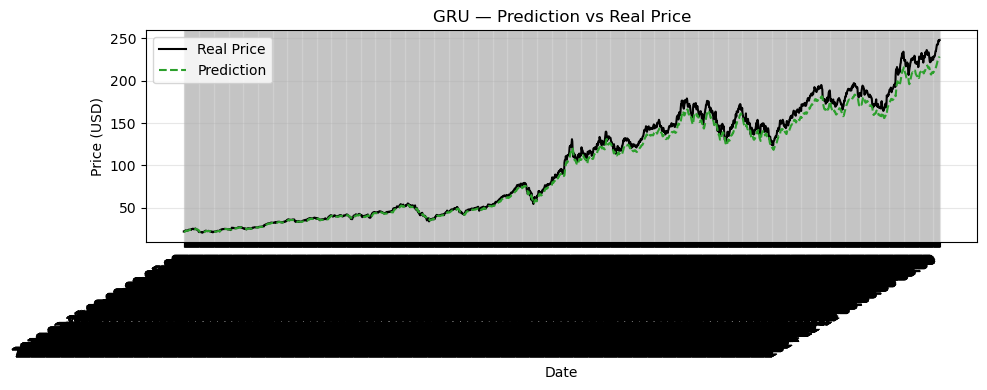

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates_test, y_real, label="Real Price", color="black", linewidth=1.5)
ax.plot(dates_test, pred_gru, label="Prediction", color="tab:green", linewidth=1.5, linestyle="--")
ax.set_title("GRU — Prediction vs Real Price", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

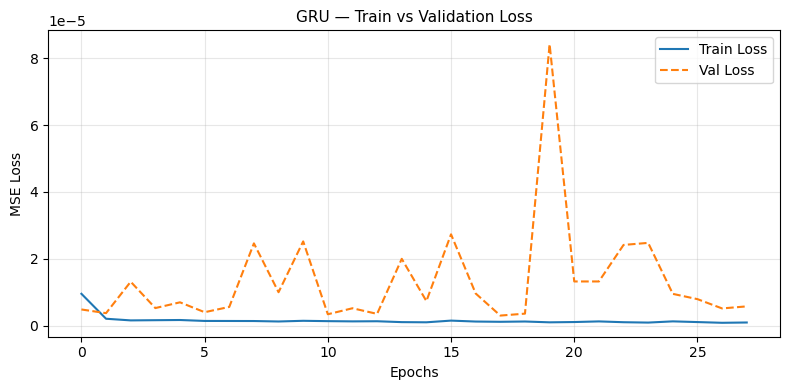

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_gru.history["loss"], label="Train Loss", linewidth=1.5)
ax.plot(history_gru.history["val_loss"], label="Val Loss", linewidth=1.5, linestyle="--")
ax.set_title("GRU — Train vs Validation Loss", fontsize=11)
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
model_bilstm = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(1)
])
model_bilstm.compile(optimizer="adam", loss="mse")

history_bilstm, pred_bilstm, _, rmse_bilstm, mae_bilstm = build_and_evaluate(
    model_bilstm, "Bidirectional LSTM", x_train, y_train, x_test, y_test, scaler
)

  Model: Bidirectional LSTM
Trained for 50 epochs (early stopping)
  RMSE: 5.0437 USD
  MAE:  3.3426 USD


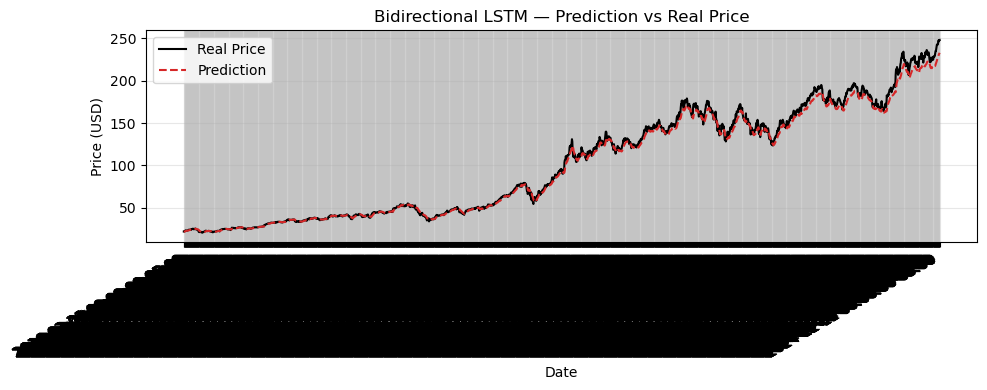

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates_test, y_real, label="Real Price", color="black", linewidth=1.5)
ax.plot(dates_test, pred_bilstm, label="Prediction", color="tab:red", linewidth=1.5, linestyle="--")
ax.set_title("Bidirectional LSTM — Prediction vs Real Price", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

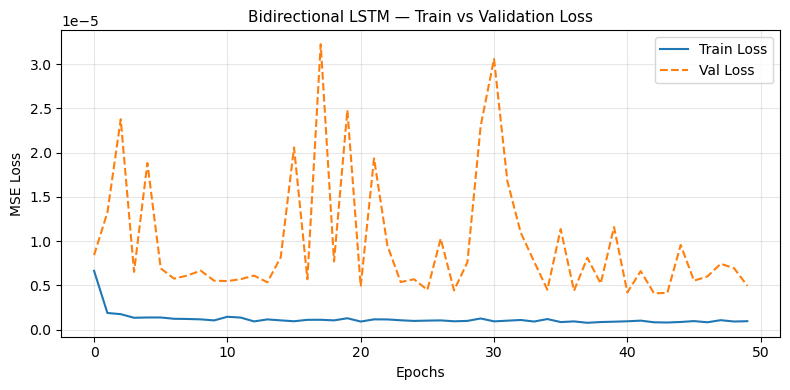

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_bilstm.history["loss"], label="Train Loss", linewidth=1.5)
ax.plot(history_bilstm.history["val_loss"], label="Val Loss", linewidth=1.5, linestyle="--")
ax.set_title("Bidirectional LSTM — Train vs Validation Loss", fontsize=11)
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
model_bigru = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    Bidirectional(GRU(64, return_sequences=False)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(1)
])
model_bigru.compile(optimizer="adam", loss="mse")

history_bigru, pred_bigru, _, rmse_bigru, mae_bigru = build_and_evaluate(
    model_bigru, "Bidirectional GRU", x_train, y_train, x_test, y_test, scaler
)

  Model: Bidirectional GRU
Trained for 42 epochs (early stopping)
  RMSE: 4.7316 USD
  MAE:  3.2369 USD


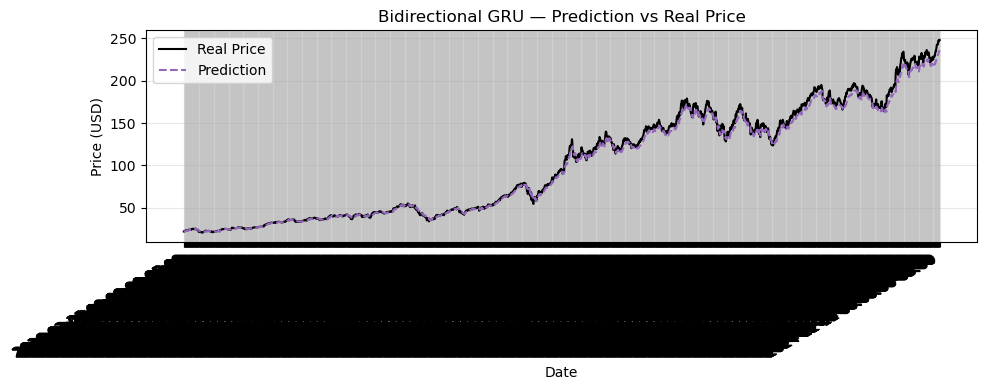

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates_test, y_real, label="Real Price", color="black", linewidth=1.5)
ax.plot(dates_test, pred_bigru, label="Prediction", color="tab:purple", linewidth=1.5, linestyle="--")
ax.set_title("Bidirectional GRU — Prediction vs Real Price", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

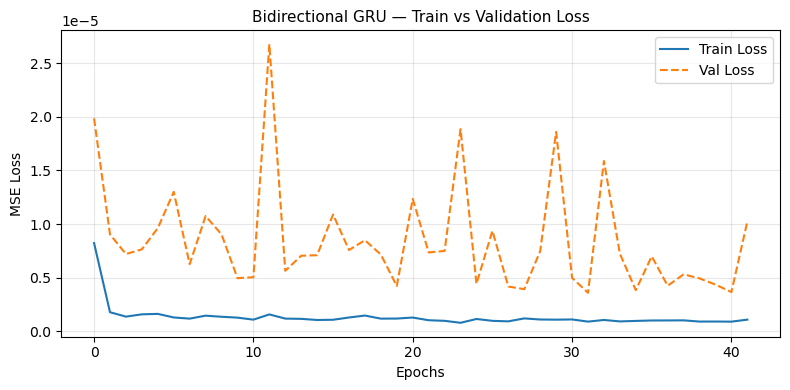

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_bigru.history["loss"], label="Train Loss", linewidth=1.5)
ax.plot(history_bigru.history["val_loss"], label="Val Loss", linewidth=1.5, linestyle="--")
ax.set_title("Bidirectional GRU — Train vs Validation Loss", fontsize=11)
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
print("  COMPARAREA MODELELOR")
print(f"{'Model':<25} {'RMSE (USD)':>12} {'MAE (USD)':>12}")
results = [
    ("SimpleRNN",          rmse_rnn,    mae_rnn),
    ("LSTM",               rmse_lstm,   mae_lstm),
    ("GRU",                rmse_gru,    mae_gru),
    ("Bidirectional LSTM", rmse_bilstm, mae_bilstm),
    ("Bidirectional GRU",  rmse_bigru,  mae_bigru),
]
for name, rmse, mae in results:
    print(f"  {name:<23} {rmse:>12.4f} {mae:>12.4f}")

best = min(results, key=lambda x: x[1])
print(f"\n  Cel mai bun model (RMSE minim): {best[0]} — RMSE = {best[1]:.4f} USD")

  COMPARAREA MODELELOR
Model                       RMSE (USD)    MAE (USD)
  SimpleRNN                    15.7455      10.8929
  LSTM                          3.8739       2.5355
  GRU                           7.7305       5.5201
  Bidirectional LSTM            5.0437       3.3426
  Bidirectional GRU             4.7316       3.2369

  Cel mai bun model (RMSE minim): LSTM — RMSE = 3.8739 USD


C:\Users\Costea\AppData\Local\Temp\ipykernel_391048\334439560.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=20, ha="right")


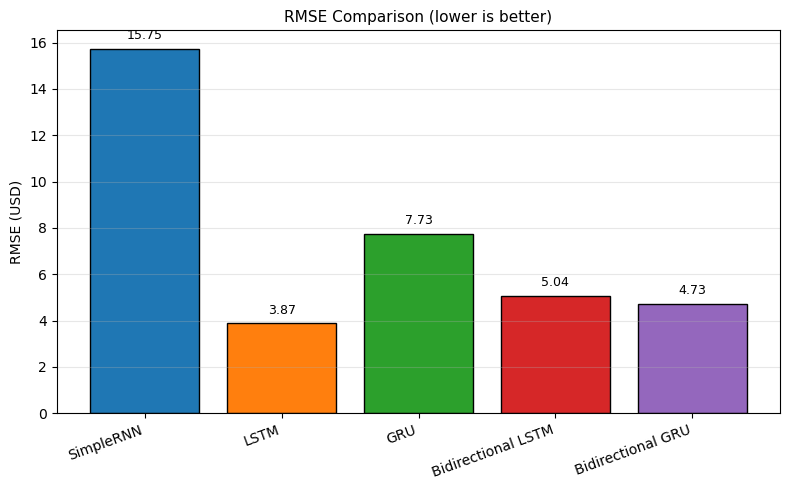

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
model_names = [r[0] for r in results]
rmse_vals   = [r[1] for r in results]
colors_bar  = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
bars = ax.bar(model_names, rmse_vals, color=colors_bar, edgecolor="black")
ax.set_title("RMSE Comparison (lower is better)", fontsize=11)
ax.set_ylabel("RMSE (USD)")
ax.set_xticklabels(model_names, rotation=20, ha="right")
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()